# Stage 01 — Ratings

Computes `ExpectedMf` (expected Fantamedia performance for the upcoming season) and prepares the output for Stage 2.

**Input:** `data/intermediate/{SEASON}/data_preprocess_merge.xlsx` (Stage 0 output)
**Output:** `data/intermediate/{SEASON}/output_rp.csv`

**Pipeline position:** Stage 00 → **Stage 01** → Stage 02 (distribution / regressors)

In [ ]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
BASE = os.getcwd()
if os.path.basename(BASE) == 'pipeline':
    BASE = os.path.abspath(os.path.join(BASE, '..'))
os.chdir(BASE)
SEASON = "25-26"
INTER_DIR = f"data/intermediate/{SEASON}"
INPUT_PATH = f"{INTER_DIR}/data_preprocess_merge.xlsx"
OUTPUT_PATH = f"{INTER_DIR}/output_rp.csv"

# Configurable parameters
roles = ['P', 'D', 'C', 'A']
# Role colors (BE contract)
role_colors = {
    'Por': '#FFB74D', 'Dc': '#64B5F6', 'B': '#64B5F6', 'Dd': '#64B5F6', 'Ds': '#64B5F6',
    'E': '#81C784', 'M': '#81C784', 'C': '#81C784', 'W': '#81C784', 'T': '#81C784', 'Pc': '#81C784',
    'A': '#E57373',
}
def get_role_color(role):
    return role_colors.get(role, '#CCCCCC')

main_colors = {'P': '#FFB74D', 'D': '#64B5F6', 'C': '#81C784', 'A': '#E57373'}

roles_m = ['Por', 'Dc', 'B', 'Dd', 'Ds', 'E', 'M', 'C', 'W', 'T', 'Pc', 'A']
seasons = None  # extracted after df load
min_matches = 11
matches_filter = [8,25,22,29,29,27,26,28,24,19,27,29]
fvm_curve_min_games = 24
age_pred_min_games = 16
w_fvm = 0.8
age_modifier_weight = 0.2
season_decay = 0.3  # 0 = no decay, >0 = exponential recency decay


## Load data

Reads the Stage 0 output (`data_preprocess_merge.xlsx`), which contains:
- Player roster: `Id`, `Role`, `Role_M`, `Name`, `Squad`, `Price`, `Age`, `FVM`
- Historical stats: `Pg{season}`, `Mv{season}`, `Mf{season}`, `FVM{season}` for each available season
- Historical FVM columns are only available from season 22-23 onward


In [103]:
df = pd.read_excel(INPUT_PATH)
seasons = sorted(set([col[2:] for col in df.columns if col.startswith("Pg")]), reverse=True)
print('Seasons extracted:', seasons)
print(df.shape)


Seasons extracted: ['24_25', '23_24', '22_23', '21_22', '20_21', '19_20']
(532, 33)


## Data overview

Distribution of Age, Role, Price, and FVM across the roster.

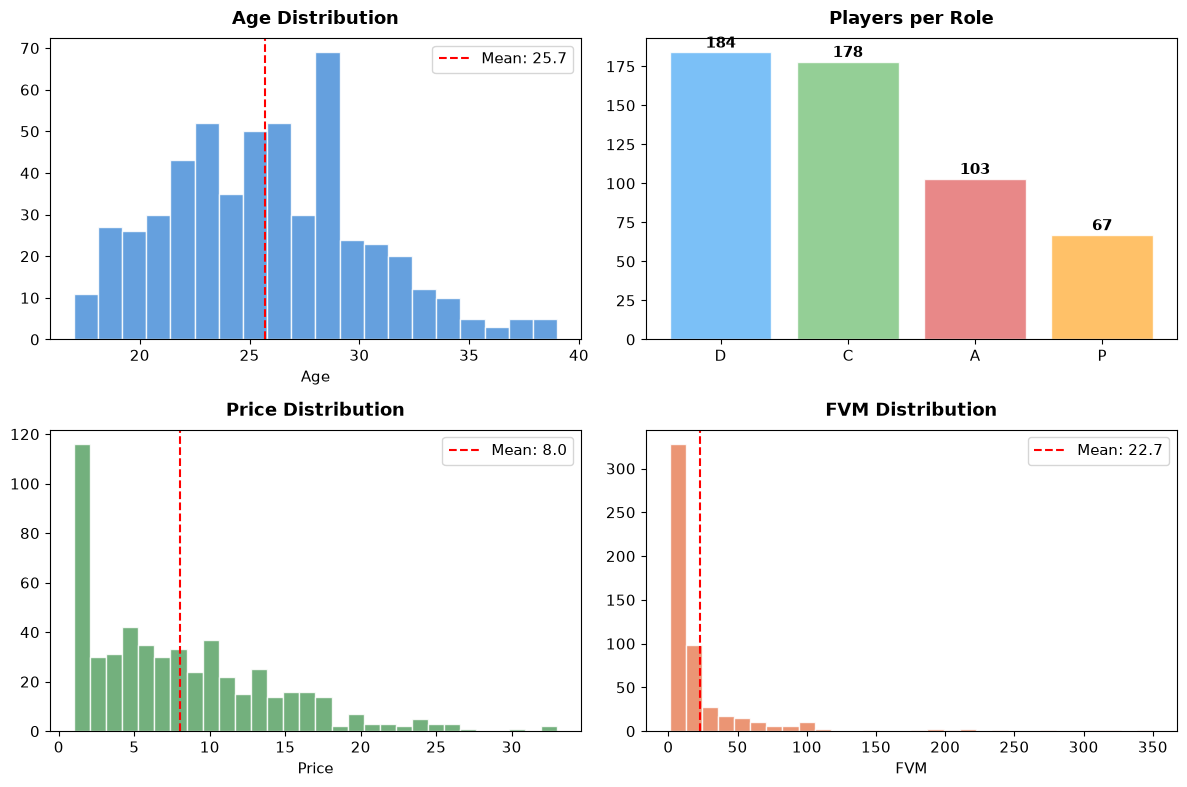

In [104]:
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 11})
fig, axes = plt.subplots(2, 2)

# Age distribution
axes[0, 0].hist(df['Age'].dropna(), bins=20, color='#4A90D9', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Age Distribution', fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Age')
axes[0, 0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 0].legend()

# Players per Role
role_counts = df['Role'].value_counts()
colors_bar = [main_colors.get(r, '#CCCCCC') for r in role_counts.index]
bars = axes[0, 1].bar(range(len(role_counts)), role_counts.values, color=colors_bar, edgecolor='white', alpha=0.85)
axes[0, 1].set_xticks(range(len(role_counts)))
axes[0, 1].set_xticklabels(role_counts.index)
axes[0, 1].set_title('Players per Role', fontweight='bold', pad=10)
for bar, val in zip(bars, role_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val), ha='center', fontweight='bold')

# Price distribution
axes[1, 0].hist(df['Price'].dropna(), bins=30, color='#5BA266', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Price Distribution', fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Price')
axes[1, 0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f"Mean: {df['Price'].mean():.1f}")
axes[1, 0].legend()

# FVM distribution
axes[1, 1].hist(df['FVM'].dropna(), bins=30, color='#E8835C', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('FVM Distribution', fontweight='bold', pad=10)
axes[1, 1].set_xlabel('FVM')
axes[1, 1].axvline(df['FVM'].mean(), color='red', linestyle='--', label=f"Mean: {df['FVM'].mean():.1f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Compute ratings

### Methodology

The expected performance for the upcoming season (`ExpectedMf`) is computed as a **weighted blend** of two independent signals:

```
ExpectedMf = w_fvm × FVM_pred + (1 - w_fvm) × hist_perf
```

Where:
- **`w_fvm`** (default 0.75): weight given to the FVM-based prediction
- **`FVM_pred`**: the performance predicted by the FVM → Mf regression for the player's role
- **`hist_perf`**: the player's own historical performance adjusted by age trajectory

### FVM → Mf regression

For each Role_M, a weighted linear regression is fitted on pooled same-season data (FVM_t → Mf_t, not lagged). Each observation is weighted by:

```
weight = clip(Pg, 0, 38) × exp(-season_decay × season_index)
```

- **Pg clipping**: caps the games-played weight at 38 (full season) to avoid extreme leverage
- **`season_decay`** (default 0.3): exponential recency decay — more recent seasons get higher weight. Season 0 (most recent) has weight 1.0, season 1 gets `exp(-0.3) ≈ 0.74`, season 2 gets `exp(-0.6) ≈ 0.55`, etc. Set to `0` to disable decay and treat all seasons equally.

### Historical performance + age delta

If the player has valid data from the most recent season (`Pg ≥ age_pred_min_games`):

```
hist_perf = Mf_last + age_modifier_weight × age_delta
```

- **`Mf_last`**: the player's actual Mf from the last season
- **`age_delta`**: the expected performance change from age N-1 to age N, derived from the quadratic age curve: `P(age) - P(age-1)`
- **`age_modifier_weight`** (default 0.2): how much of the age curve delta to apply. A value of 0.2 means only 20% of the predicted age shift is applied, keeping the player's own history as the dominant signal.

If the player lacks recent data, the fallback is the age curve prediction for their role. If no age curve exists, the FVM prediction is used as-is.

### Role merge: Ds → Dd


In [105]:
# Subset by Role_M – merge Ds into Dd
df_m = []
for role in roles_m:
    if role == 'Dd':
        df_temp = df[df['Role_M'].str.split(';').str[0].isin(['Dd','Ds'])]
    else:
        df_temp = df[df['Role_M'].str.split(';').str[0] == role]
    df_m.append(df_temp)

def expected_performance(x_values, model):
    return model(x_values)
def expected_diff_performance(age, model):
    return expected_performance(age, model) - expected_performance(age-1, model)

# Fit age-performance models with recency weighting
stats_models = []
for i, df_temp in enumerate(df_m):
    players = []
    for _, row in df_temp.iterrows():
        for k, s in enumerate(seasons):
            if row['Pg'+s] >= matches_filter[i]:
                season_weight = np.exp(-season_decay * k)
                players.append({'Name':row['Name'], 'Age':row['Age']-1-k, 'MfPerformance':row['Mf'+s], 'season_weight': season_weight})
    new_df = pd.DataFrame(players)
    new_df = new_df[new_df['Age'] <= 34]
    if len(new_df) > 0:
        age_groups = new_df.groupby('Age').apply(lambda g: np.average(g['MfPerformance'], weights=g['season_weight']))
        avg = age_groups
    else:
        avg = pd.Series(dtype=float)
    if len(avg) >= 3:
        p = Polynomial.fit(avg.index, avg.values, deg=2)
        stats_models.append(p)
    else:
        stats_models.append(None)

# Fit FVM-performance models - pooled same-season FVM_t -> Mf_t with weighted linear monotone
fvm_models = []
for i, df_temp in enumerate(df_m):
    data = []
    for _, row in df_temp.iterrows():
        for j, s in enumerate(seasons):
            fvm_col = f'FVM{s}'
            mf_col  = f'Mf{s}'
            pg_col  = f'Pg{s}'
            if pg_col in row and mf_col in row and fvm_col in row:
                try:
                    pg_val = row[pg_col]
                    if pd.notna(pg_val) and pg_val >= fvm_curve_min_games:
                        fvm_val = row[fvm_col]
                        mf_val = row[mf_col]
                        if pd.notna(fvm_val) and pd.notna(mf_val) and fvm_val > 0 and mf_val > 0:
                            season_weight = np.exp(-season_decay * j)
                            data.append({'FVM': fvm_val, 'MfPerformance': mf_val, 'Pg': pg_val, 'season_weight': season_weight})
                except Exception:
                    pass
    new_df = pd.DataFrame(data)
    if len(new_df) >= 10:
        new_df['w'] = np.clip(new_df['Pg'], 0, 38) * new_df['season_weight']
        w_sum = new_df['w'].sum()
        if w_sum > 0:
            new_df['w'] = new_df['w'] / w_sum
        coef = np.polyfit(new_df['FVM'].values, new_df['MfPerformance'].values, 1, w=new_df['w'].values)
        model = np.poly1d(coef)
        fvm_models.append(model)
    else:
        fvm_models.append(None)

# Compute ExpectedMf - hybrid FVM + historical
df['ExpectedMf'] = np.nan
role_norm_map = {'Ds':'Dd'}
errors = []
for idx, row in df.iterrows():
    try:
        if pd.isna(row.get('Role_M')):
            continue
        if pd.isna(row.get('Age')):
            continue
        role = row['Role_M'].split(';')[0]
        role = role_norm_map.get(role, role)
        if role not in roles_m:
            continue
        i = roles_m.index(role)
        fvm_val = row.get('FVM')
        if fvm_models[i] is not None and pd.notna(fvm_val):
            fvm_perf = float(fvm_models[i](fvm_val))
        else:
            fvm_perf = 5.0
        mf_last = row.get(f'Mf{seasons[0]}')
        pg_last = row.get(f'Pg{seasons[0]}')
        if pd.notna(mf_last) and pd.notna(pg_last) and mf_last != 0 and pg_last >= age_pred_min_games and stats_models[i] is not None:
            age_delta = float(expected_diff_performance(row['Age'], stats_models[i]))
            hist_perf = float(mf_last) + age_modifier_weight * age_delta
        else:
            if stats_models[i] is not None:
                hist_perf = float(expected_performance(row['Age'], stats_models[i]))
            else:
                hist_perf = fvm_perf
        expected_mf = w_fvm * fvm_perf + (1 - w_fvm) * hist_perf
        df.at[idx, 'ExpectedMf'] = round(expected_mf, 2)
    except Exception as e:
        errors.append((row.get('Name'), row.get('Id'), str(e)))
        continue
if errors:
    print(f"ExpectedMf: {len(errors)} rows raised exceptions, first 5:")
    for name, pid, msg in errors[:5]:
        print(name, pid, msg)
else:
    print(f"ExpectedMf: no exceptions, w_fvm={w_fvm}, age_modifier_weight={age_modifier_weight}, season_decay={season_decay}")



ExpectedMf: no exceptions, w_fvm=0.8, age_modifier_weight=0.2, season_decay=0.3


## Age-performance histograms per Role_M

Average Mf performance grouped by age for each sub-role. Shows the typical career arc per position.

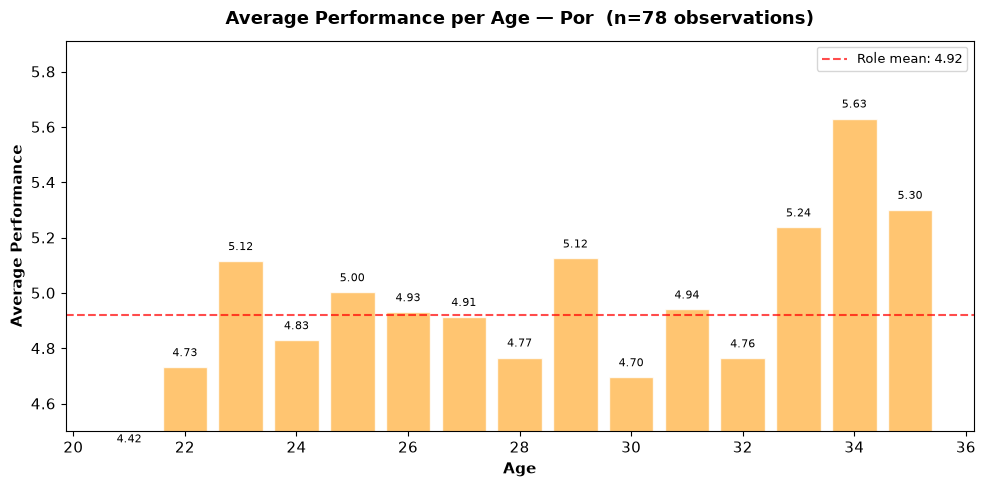

Por: avg perf = 4.92, n=78



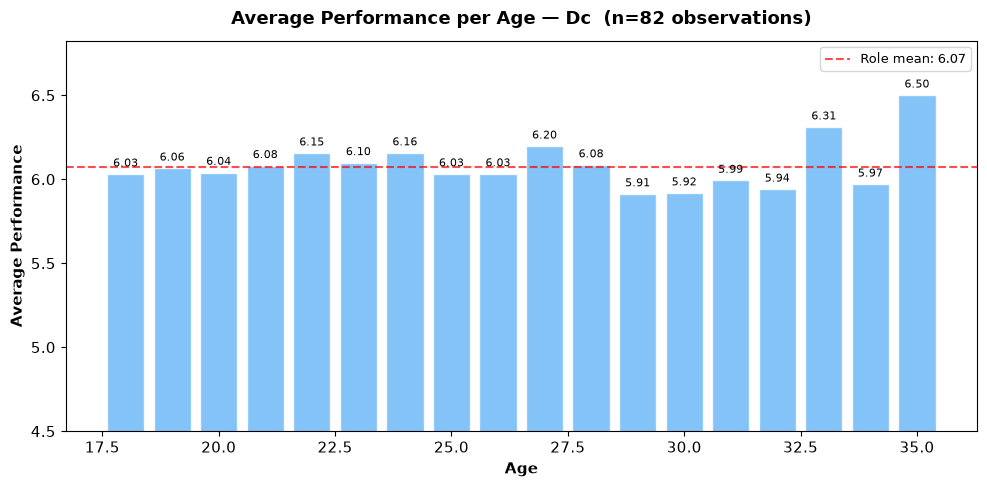

Dc: avg perf = 6.07, n=82



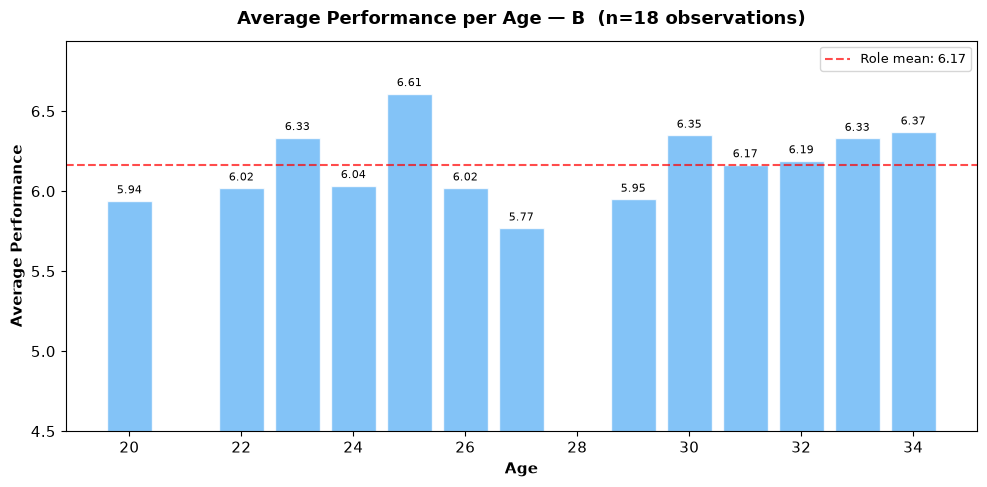

B: avg perf = 6.17, n=18



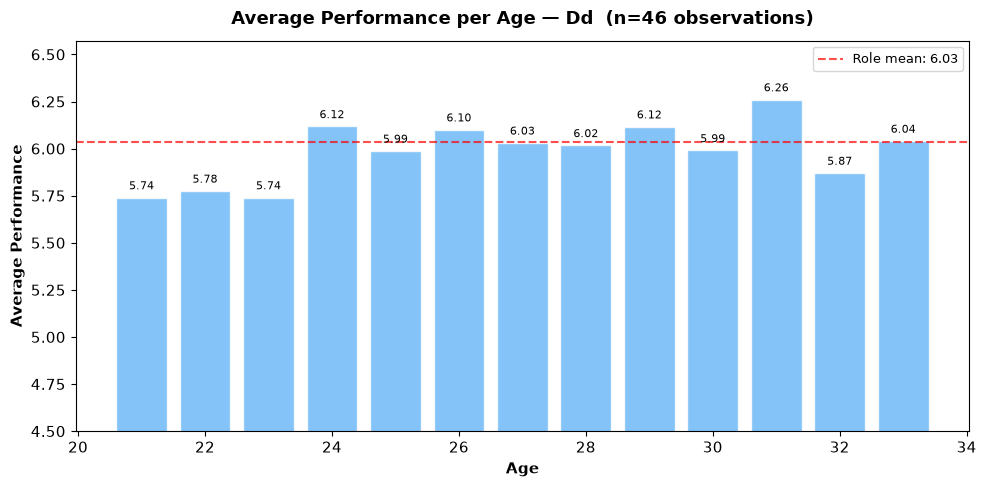

Dd: avg perf = 6.03, n=46



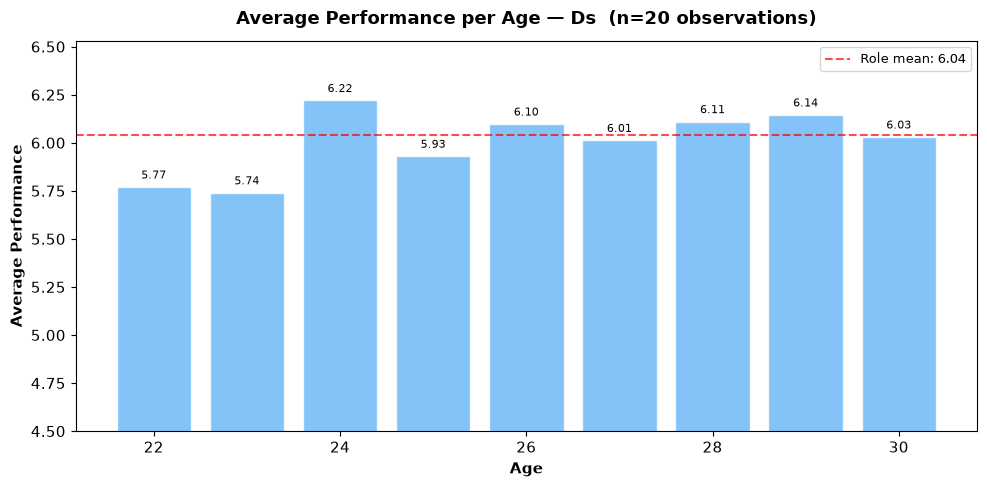

Ds: avg perf = 6.04, n=20



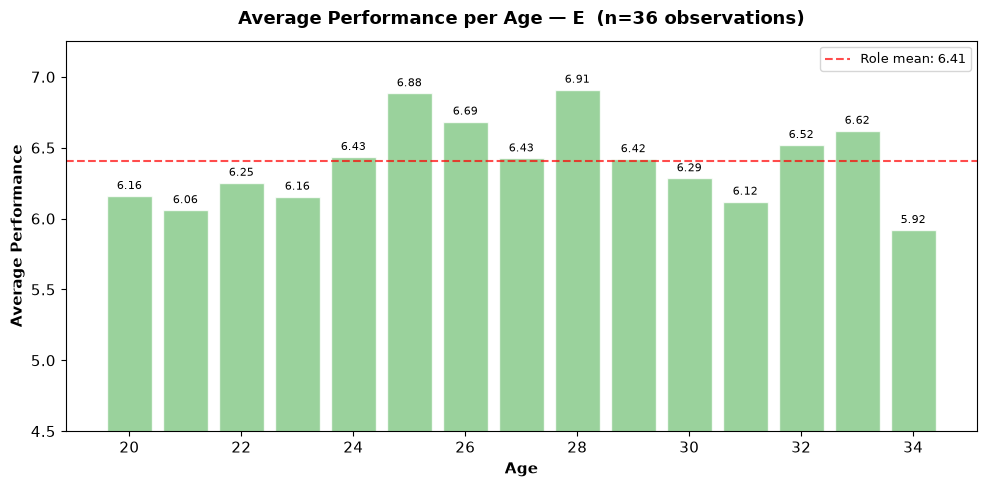

E: avg perf = 6.41, n=36



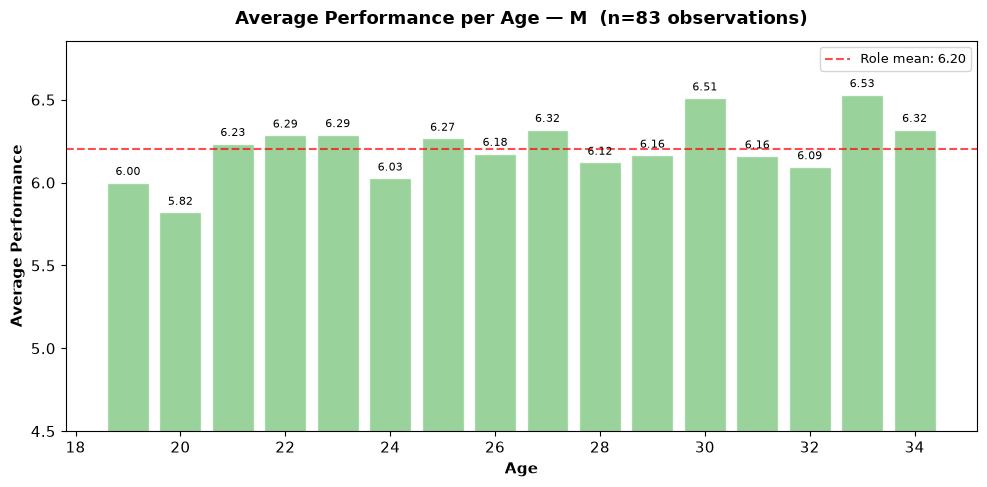

M: avg perf = 6.20, n=83



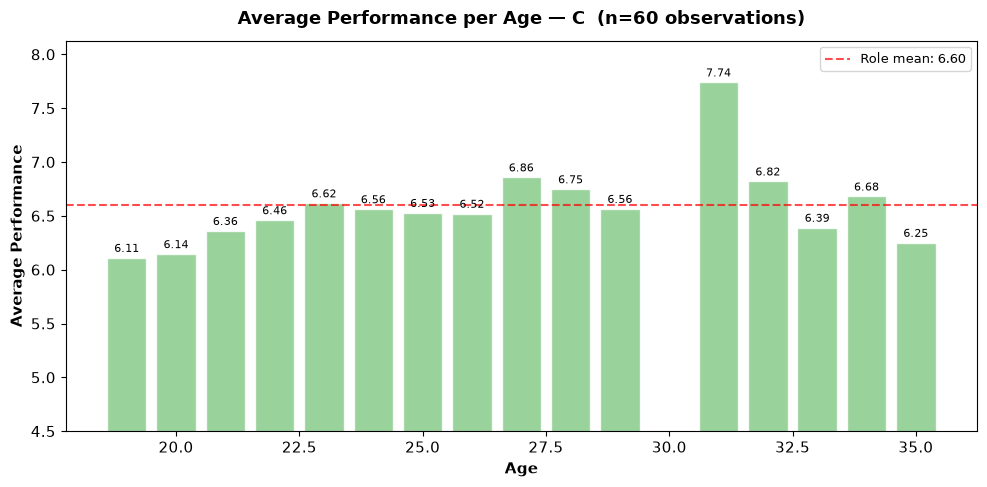

C: avg perf = 6.60, n=60



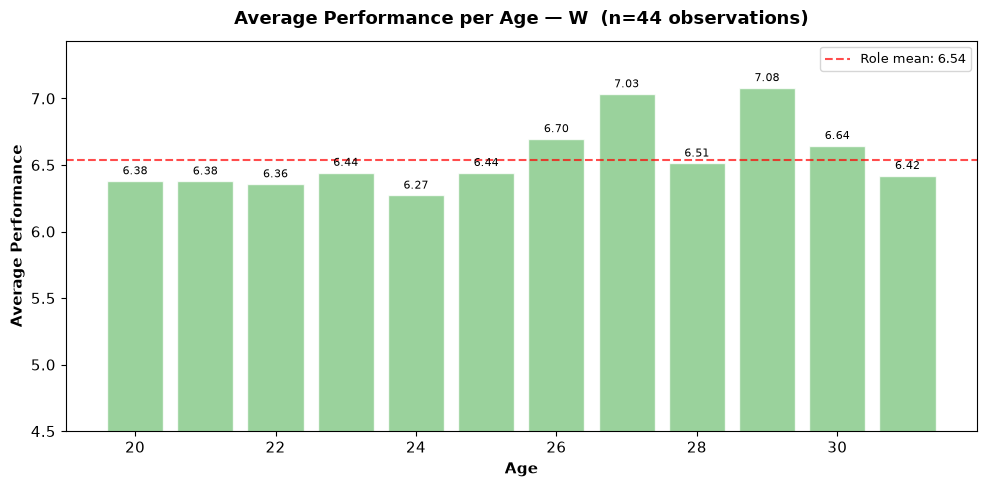

W: avg perf = 6.54, n=44



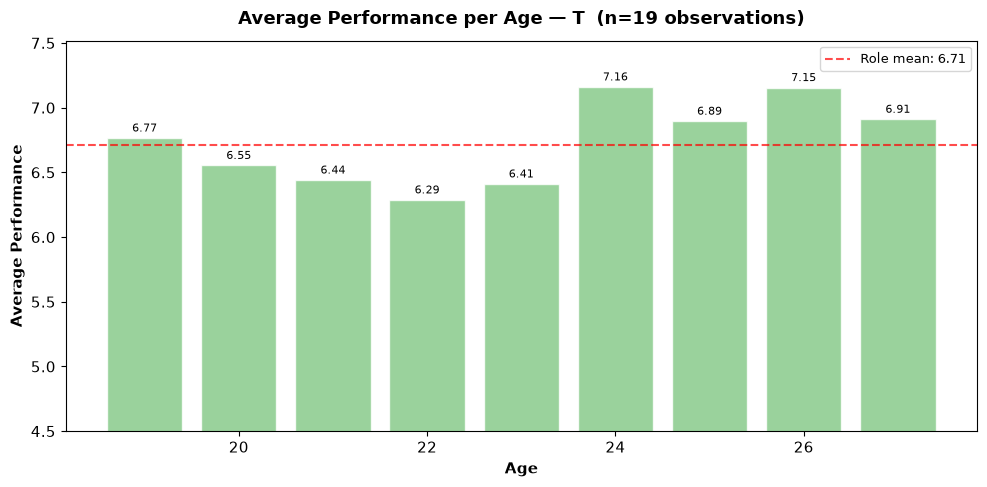

T: avg perf = 6.71, n=19



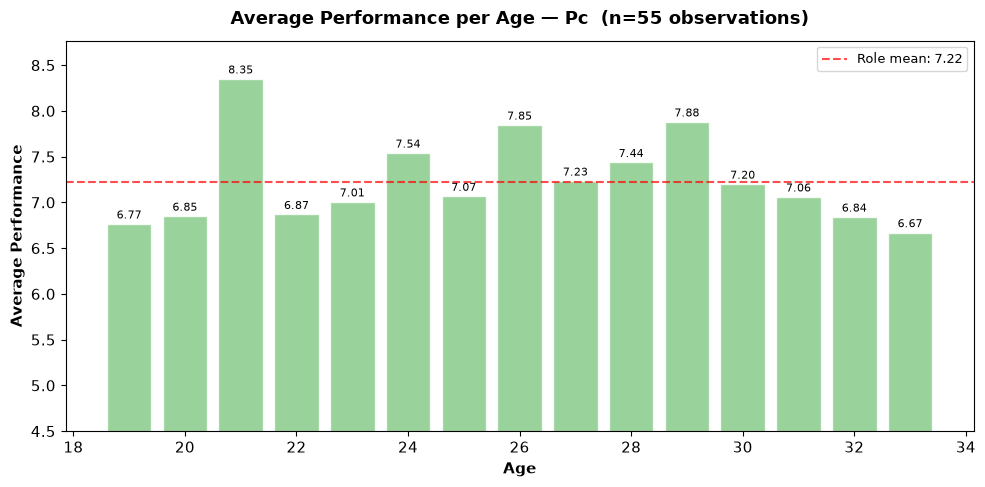

Pc: avg perf = 7.22, n=55



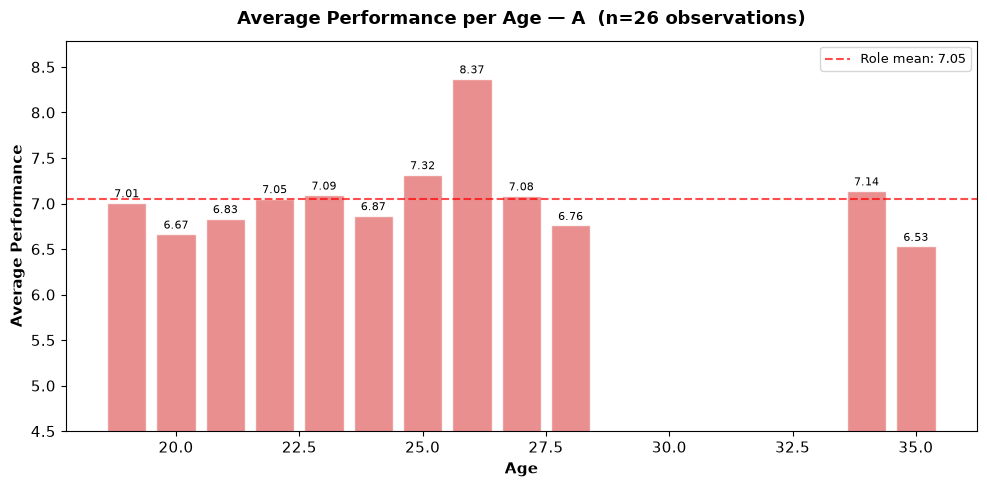

A: avg perf = 7.05, n=26



In [106]:
# Age-performance histograms per Role_M
for i, df_temp in enumerate(df_m):
    role = roles_m[i]
    color = get_role_color(role)
    players = []
    for _, row in df_temp.iterrows():
        for k, s in enumerate(seasons):
            if row['Pg'+s] >= matches_filter[i]:
                players.append({'Name': row['Name'], 'Age': row['Age']-1-k, 'MfPerformance': row['Mf'+s]})
    new_df = pd.DataFrame(players)
    if len(new_df) == 0:
        continue
    avg = new_df.groupby('Age')['MfPerformance'].mean()
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(avg.index, avg.values, color=color, edgecolor='white', alpha=0.8)
    ax.set_ylim(bottom=4.5)
    ax.set_xlabel('Age', fontweight='bold')
    ax.set_ylabel('Average Performance', fontweight='bold')
    ax.set_title(f'Average Performance per Age — {role}  (n={len(new_df)} observations)', fontweight='bold', pad=12)
    # Annotate bars with values
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    # Add mean line
    ax.axhline(new_df['MfPerformance'].mean(), color='red', linestyle='--', alpha=0.7,
                label=f"Role mean: {new_df['MfPerformance'].mean():.2f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f'{role}: avg perf = {new_df["MfPerformance"].mean():.2f}, n={len(new_df)}')
    print()




## Polynomial curve fits

Quadratic polynomial fitted to age-performance averages. Used to compute the age delta modifier for ExpectedMf.

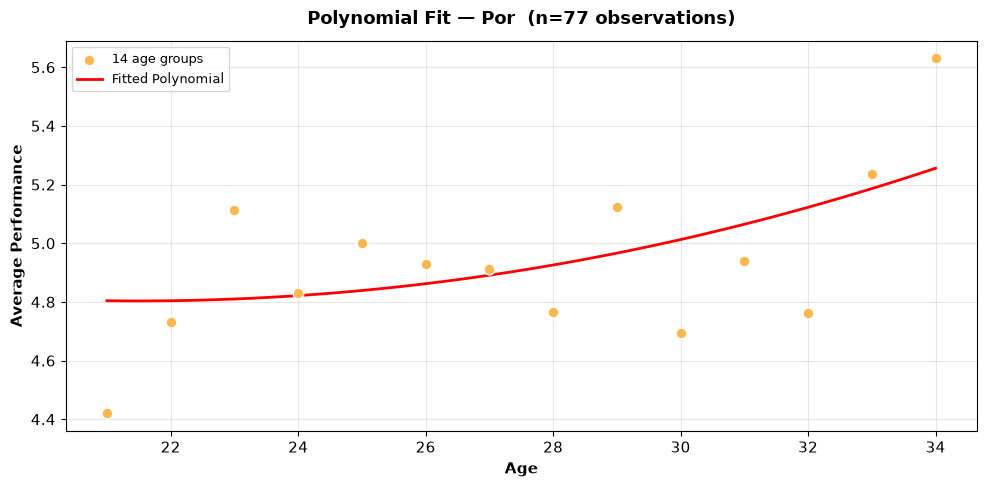

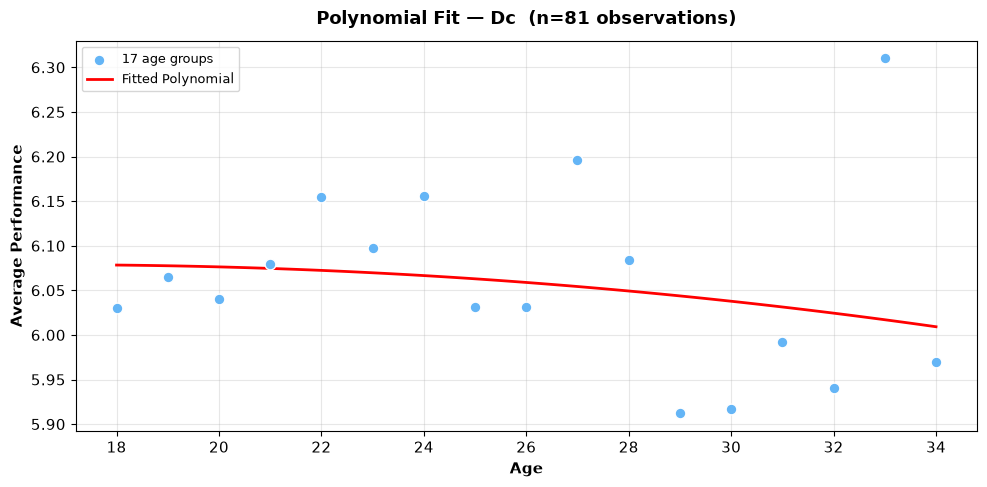

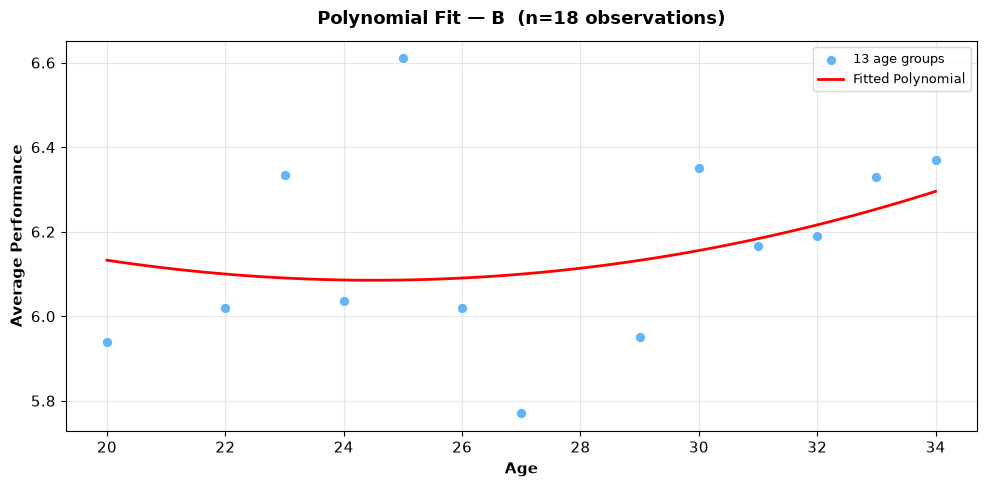

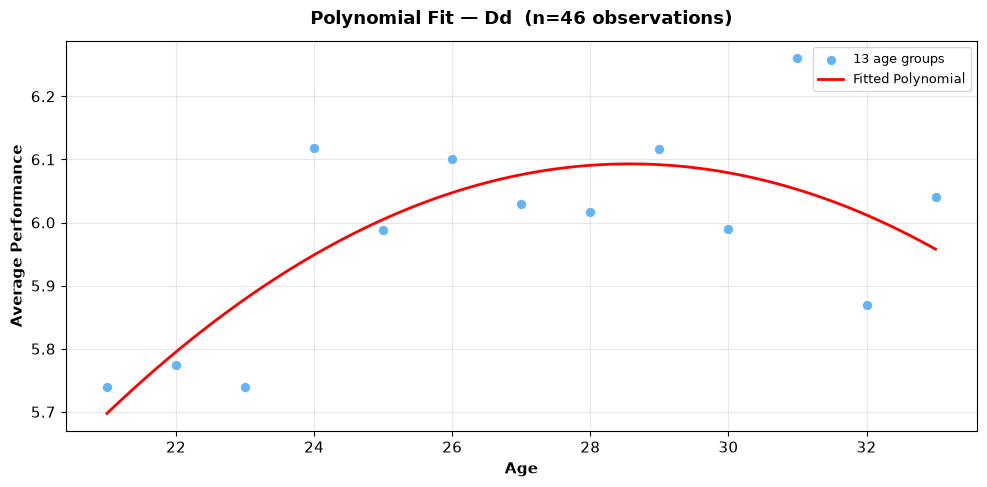

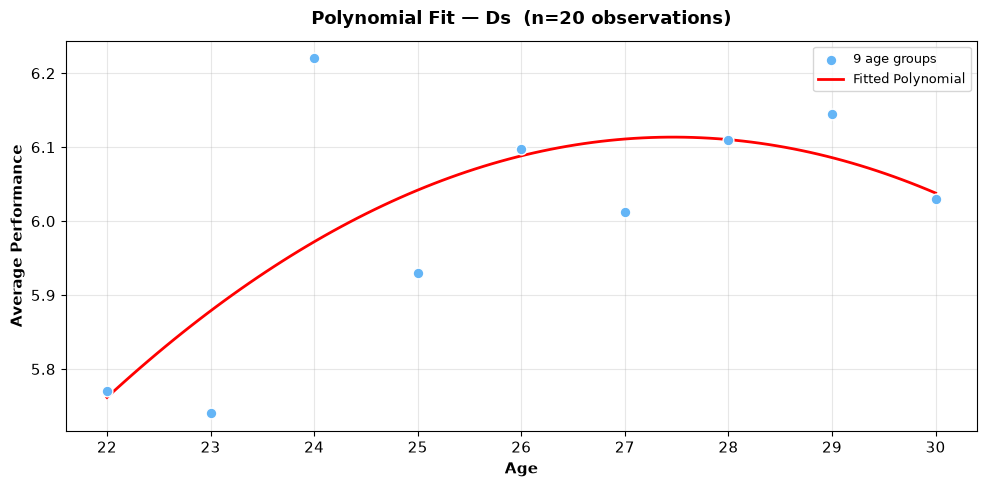

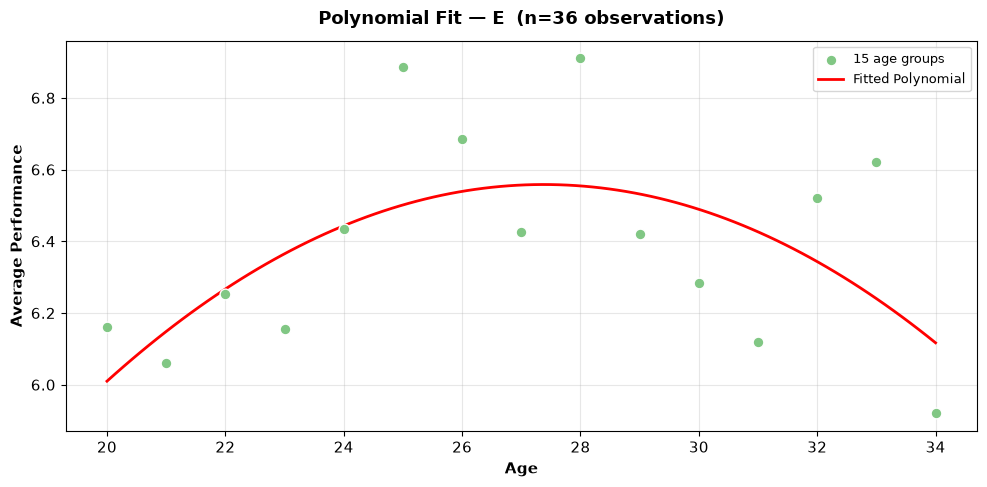

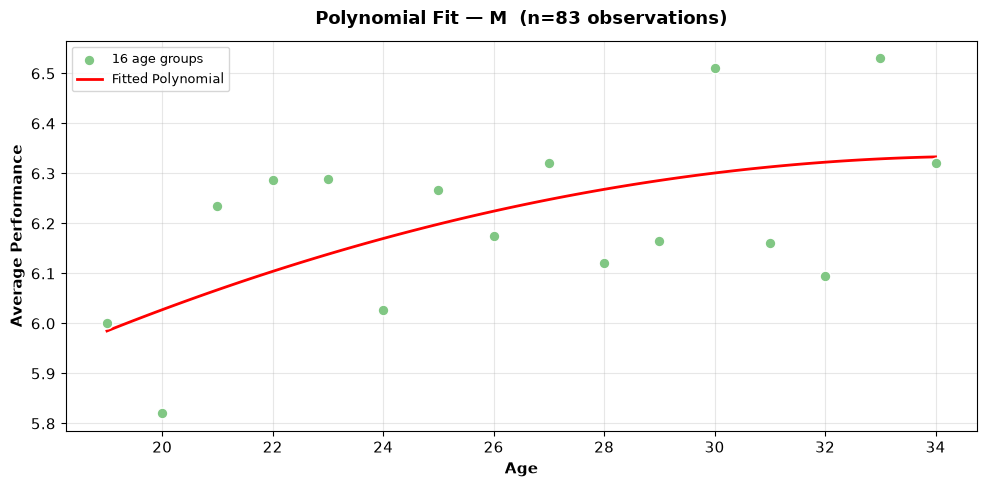

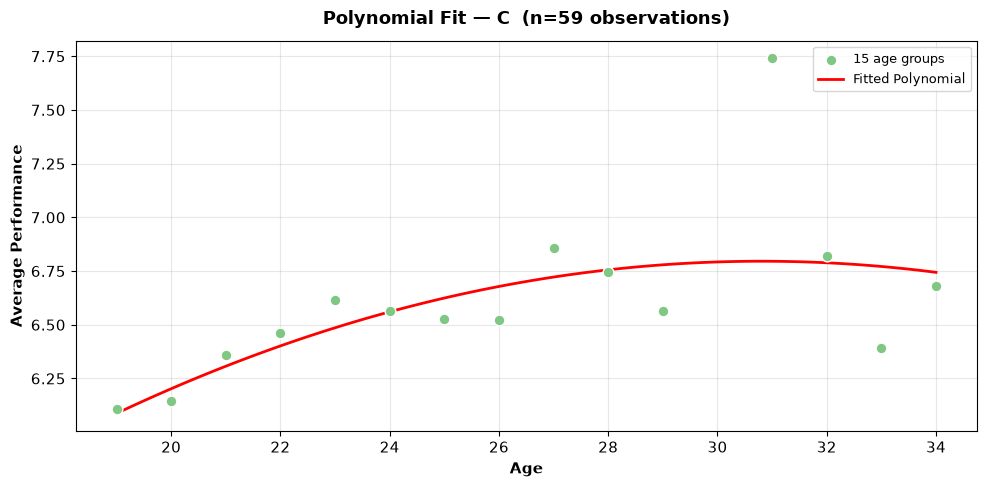

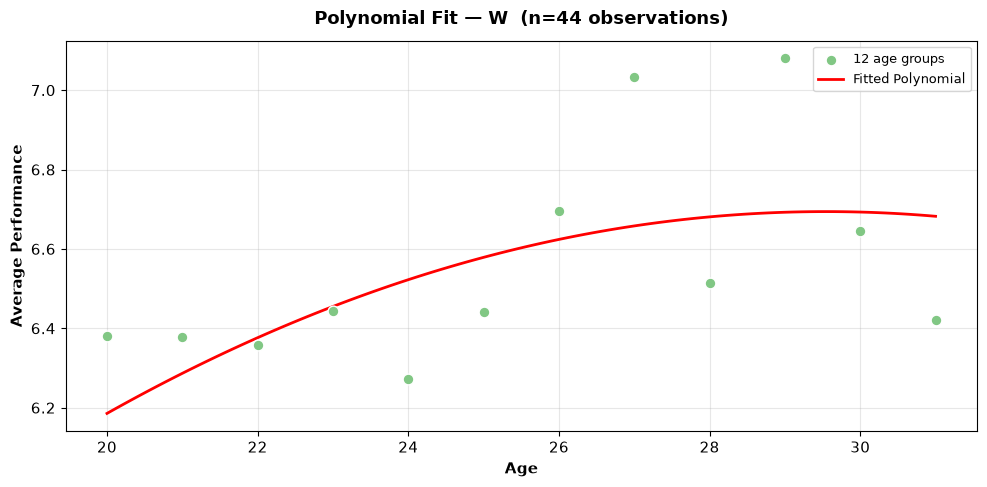

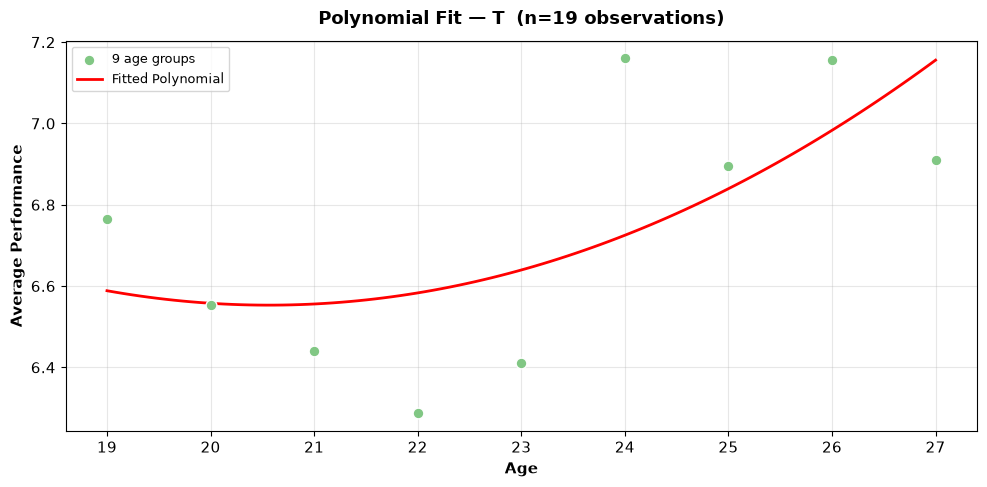

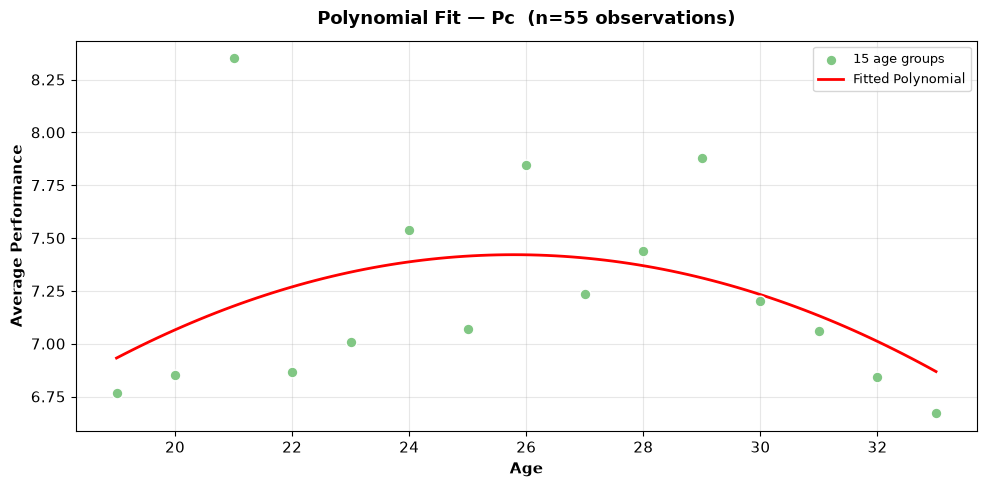

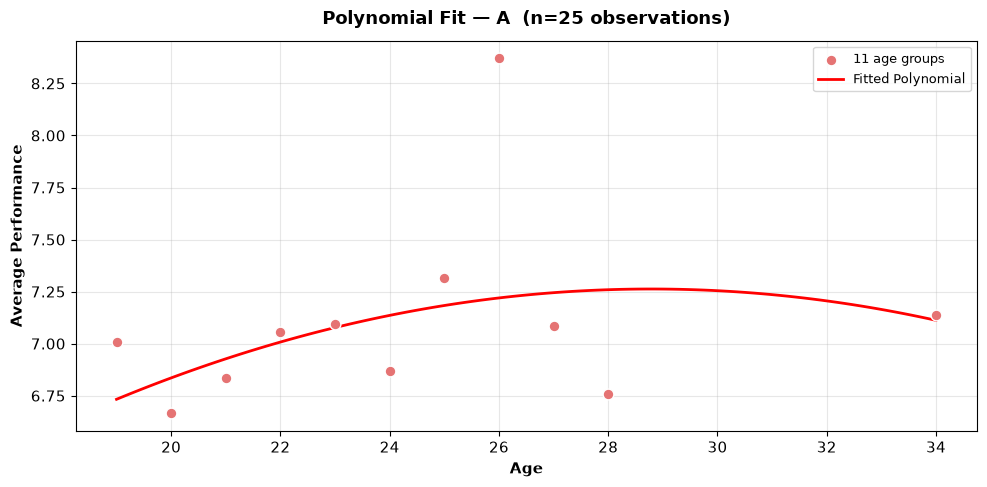

In [107]:
# Polynomial curve fits (age-performance)
for i, p in enumerate(stats_models):
    if p is None:
        continue
    role = roles_m[i]
    color = get_role_color(role)
    df_temp = df_m[i]
    players = []
    for _, row in df_temp.iterrows():
        for k, s in enumerate(seasons):
            if row['Pg'+s] >= matches_filter[i]:
                players.append({'Name': row['Name'], 'Age': row['Age']-1-k, 'MfPerformance': row['Mf'+s]})
    new_df = pd.DataFrame(players)
    new_df = new_df[new_df['Age'] <= 34]
    avg = new_df.groupby('Age')['MfPerformance'].mean()
    x_fit = np.linspace(min(avg.index), max(avg.index), 100)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(avg.index, avg.values, color=color, s=60, edgecolors='white', zorder=3, label=f'{len(avg)} age groups')
    ax.plot(x_fit, p(x_fit), 'r-', linewidth=2, label='Fitted Polynomial')
    ax.set_xlabel('Age', fontweight='bold')
    ax.set_ylabel('Average Performance', fontweight='bold')
    ax.set_title(f'Polynomial Fit — {role}  (n={len(new_df)} observations)', fontweight='bold', pad=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()




## FVM-performance histograms

Average Mf performance grouped by FVM value (current season only). Shows how FVM translates to actual performance per role.

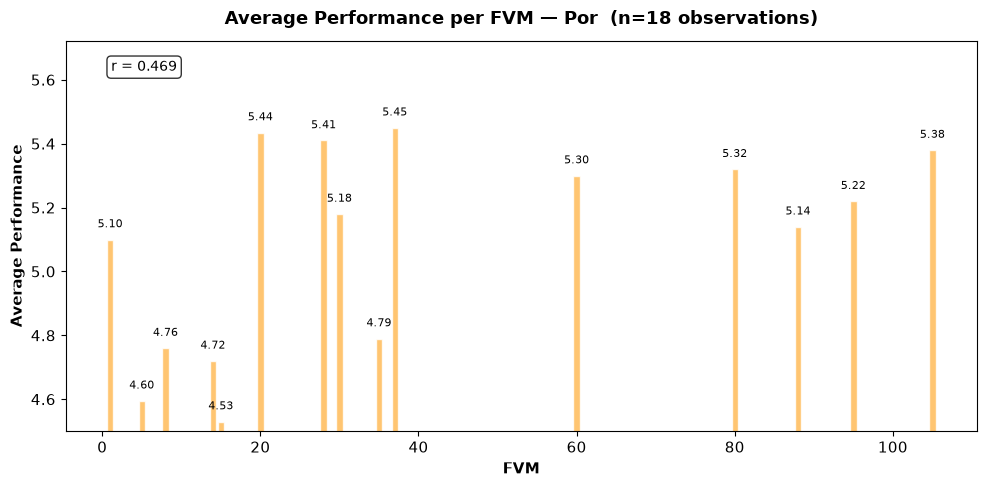

Por: FVM-Mf correlation = 0.469, n=18



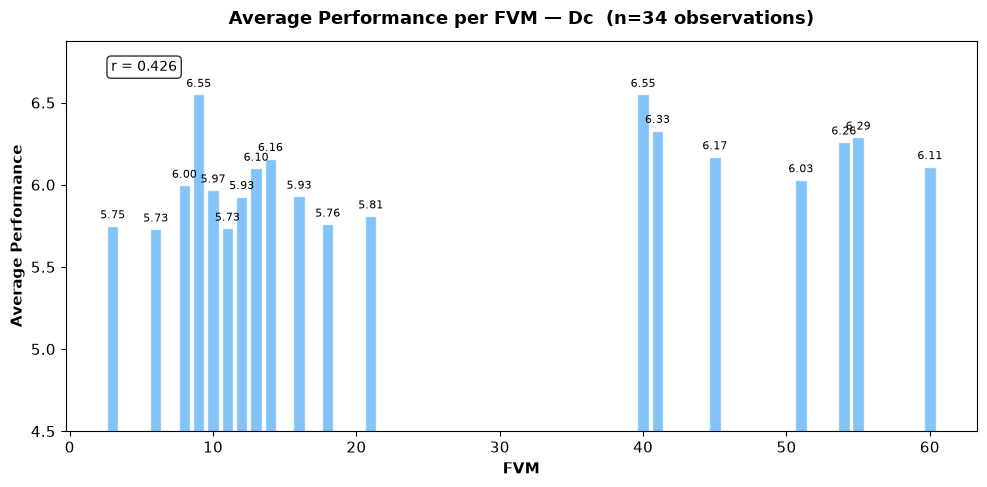

Dc: FVM-Mf correlation = 0.426, n=34



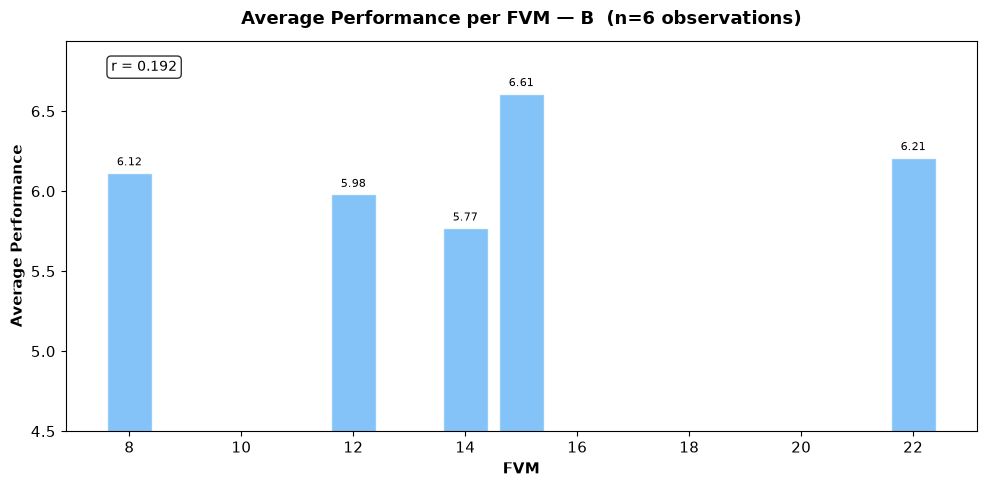

B: FVM-Mf correlation = 0.192, n=6



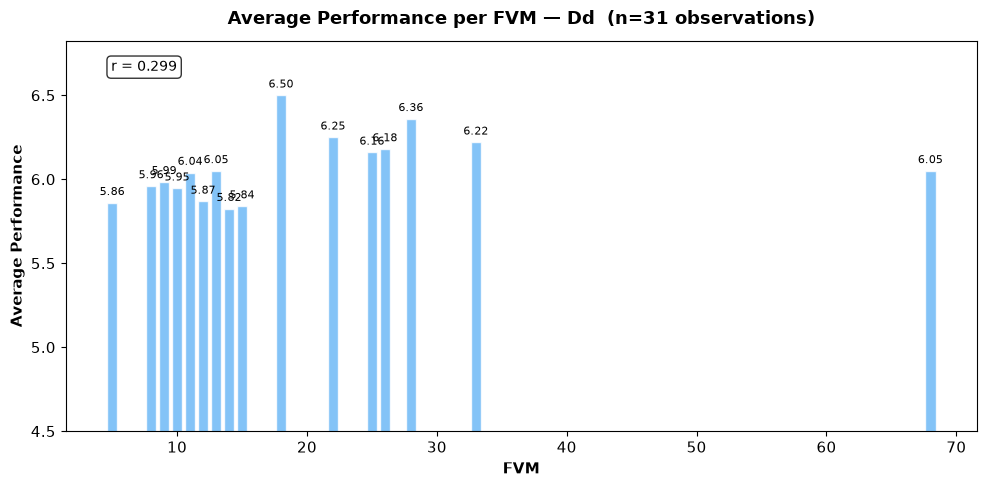

Dd: FVM-Mf correlation = 0.299, n=31



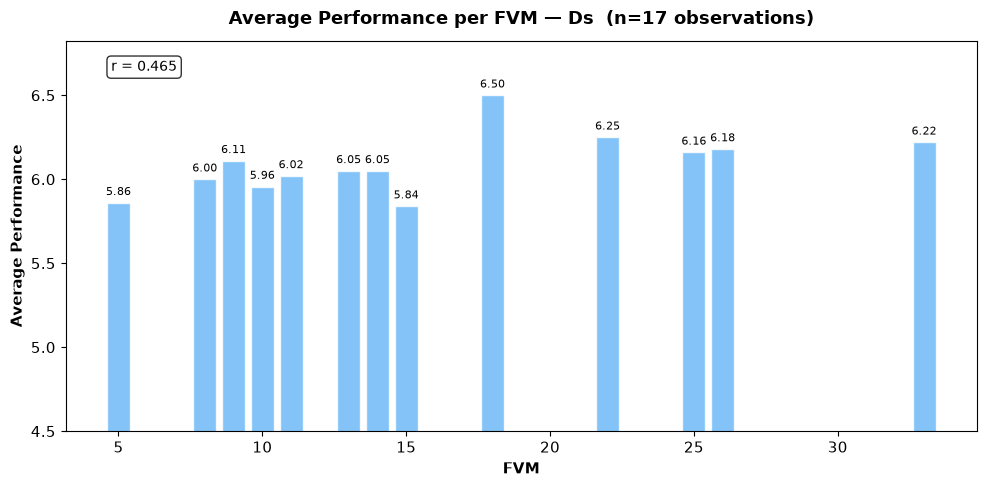

Ds: FVM-Mf correlation = 0.465, n=17



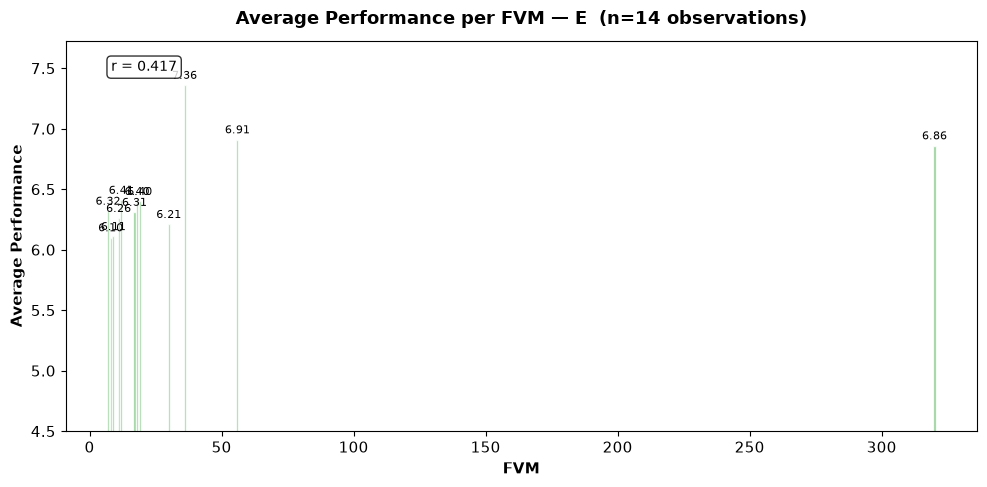

E: FVM-Mf correlation = 0.417, n=14



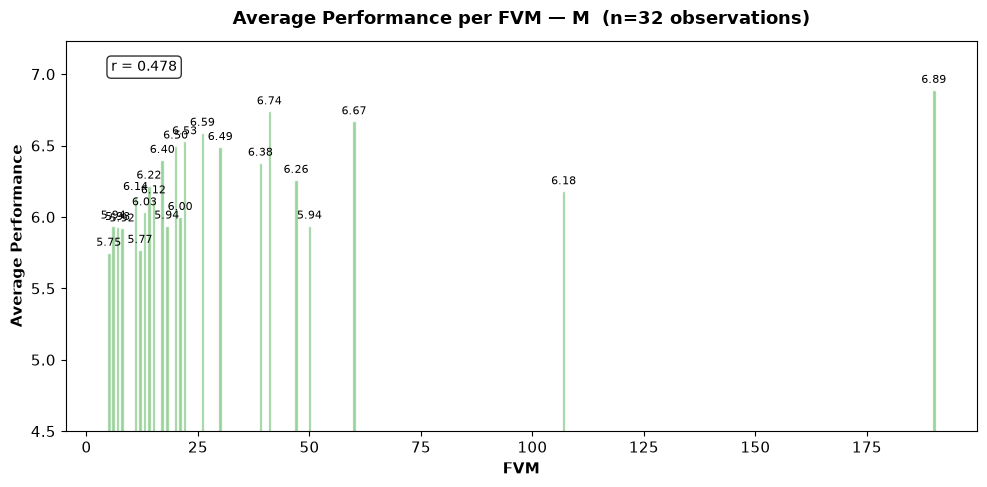

M: FVM-Mf correlation = 0.478, n=32



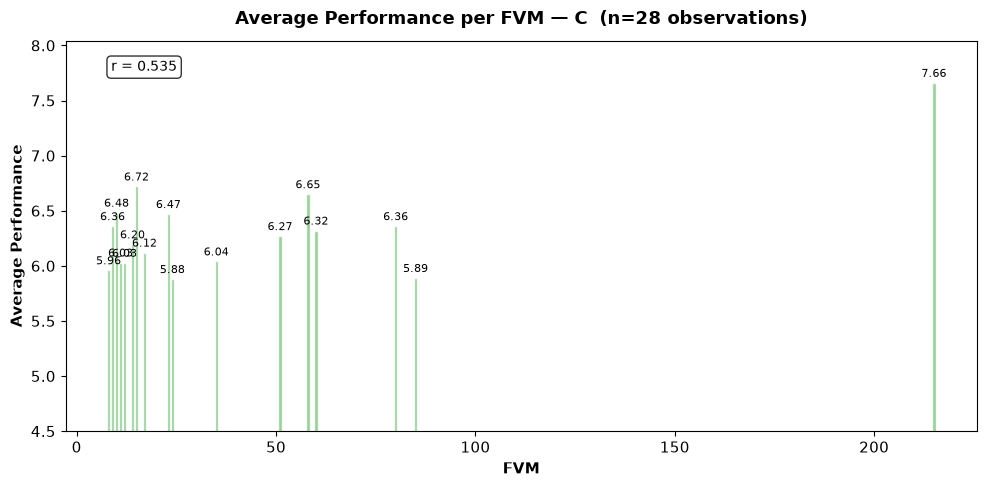

C: FVM-Mf correlation = 0.535, n=28



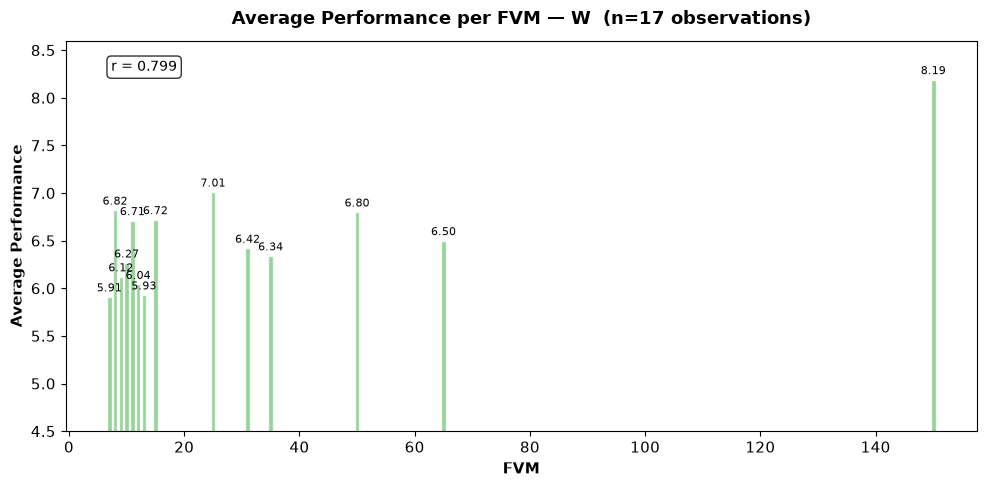

W: FVM-Mf correlation = 0.799, n=17



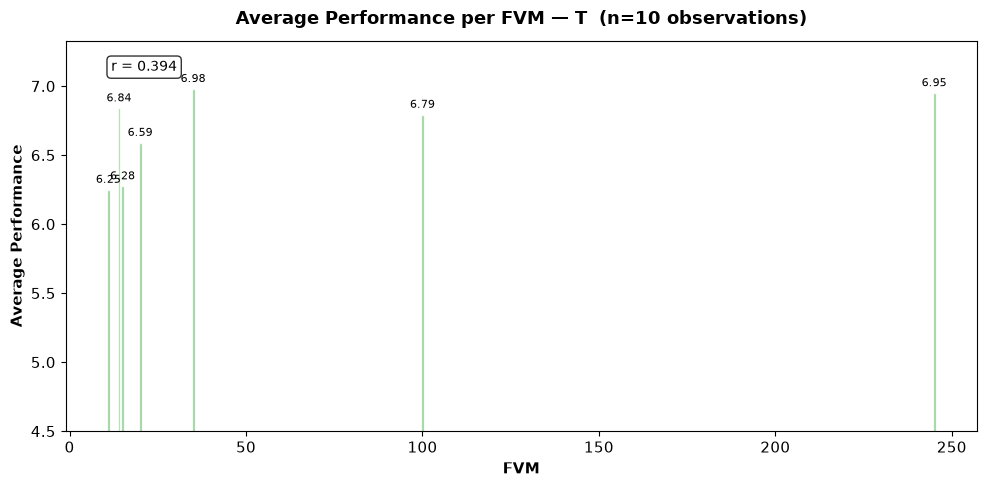

T: FVM-Mf correlation = 0.394, n=10



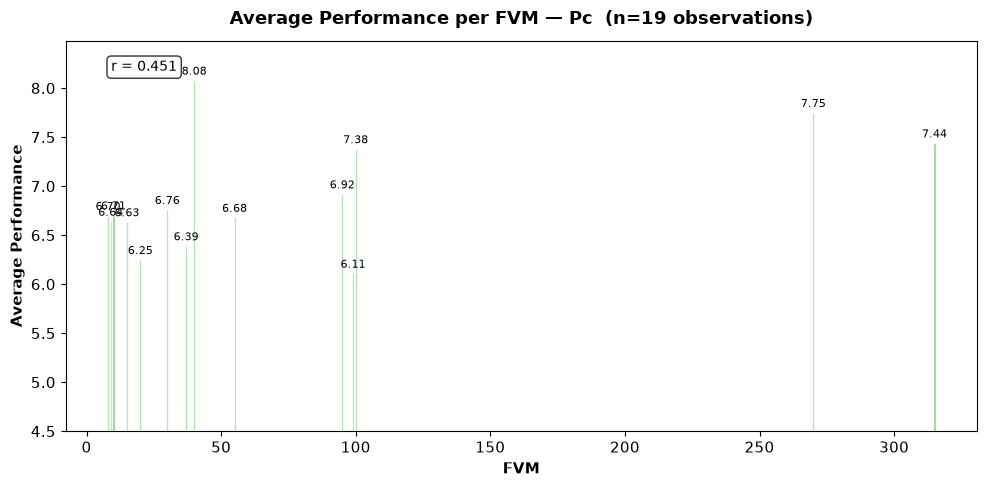

Pc: FVM-Mf correlation = 0.451, n=19



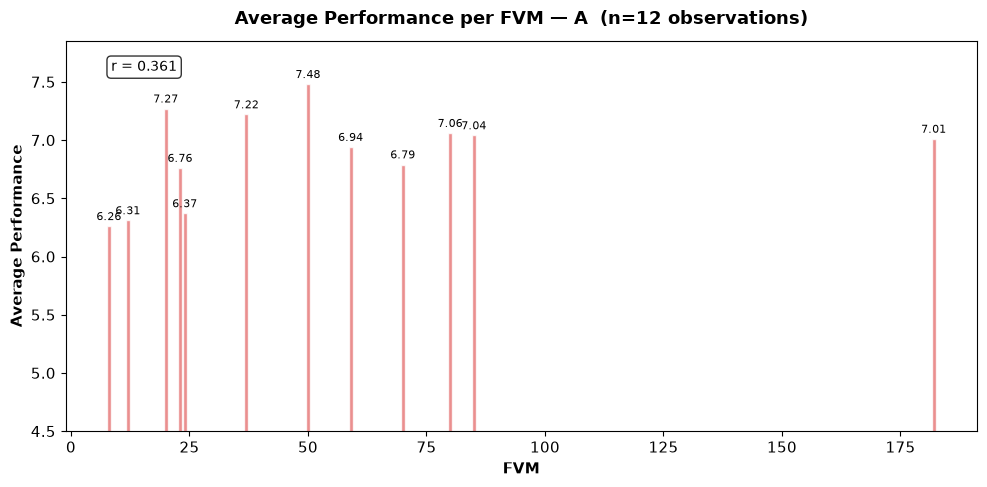

A: FVM-Mf correlation = 0.361, n=12



In [108]:
# FVM-performance histograms
for i, df_temp in enumerate(df_m):
    role = roles_m[i]
    color = get_role_color(role)
    players = []
    for _, row in df_temp.iterrows():
        if row['Pg'+seasons[0]] >= fvm_curve_min_games:
            players.append({'Name': row['Name'], 'FVM': row['FVM'], 'MfPerformance': row['Mf'+seasons[0]]})
    new_df = pd.DataFrame(players)
    if len(new_df) == 0:
        continue
    avg = new_df.groupby('FVM')['MfPerformance'].mean()
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(avg.index, avg.values, color=color, edgecolor='white', alpha=0.8)
    ax.set_ylim(bottom=4.5)
    ax.set_xlabel('FVM', fontweight='bold')
    ax.set_ylabel('Average Performance', fontweight='bold')
    ax.set_title(f'Average Performance per FVM — {role}  (n={len(new_df)} observations)', fontweight='bold', pad=12)
    # Annotate bars
    for bar, val in zip(bars, avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    # Add correlation
    corr = np.corrcoef(new_df['FVM'].values, new_df['MfPerformance'].values)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()
    print(f'{role}: FVM-Mf correlation = {corr:.3f}, n={len(new_df)}')
    print()




## FVM weighted linear regression plots

Pooled same-season FVM → Mf regression across all available seasons, weighted by games played and recency. Used as the FVM component of ExpectedMf.

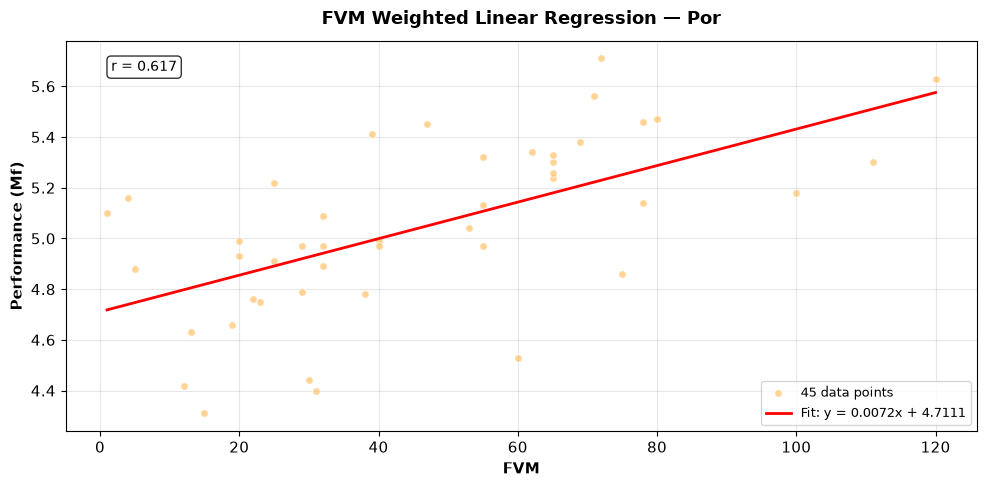

Por: r=0.617, slope=0.0072, intercept=4.7111, n=45



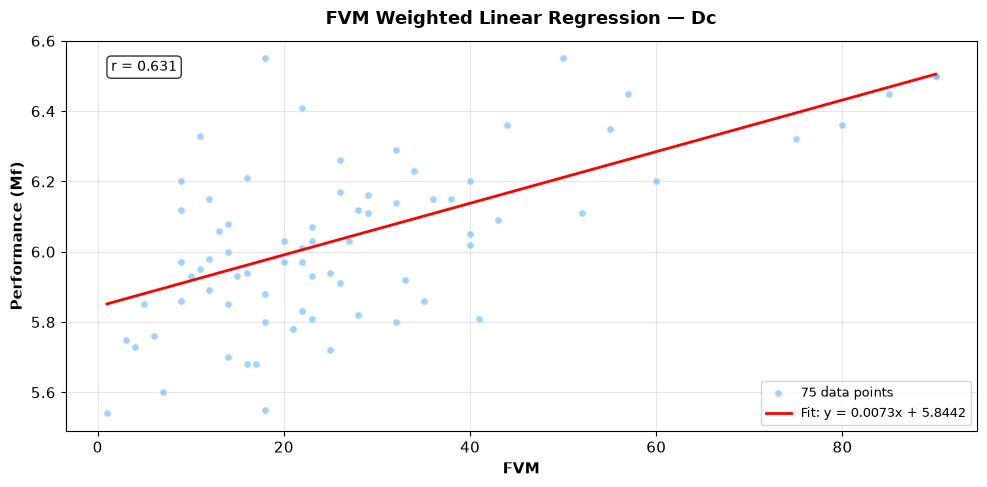

Dc: r=0.631, slope=0.0073, intercept=5.8442, n=75



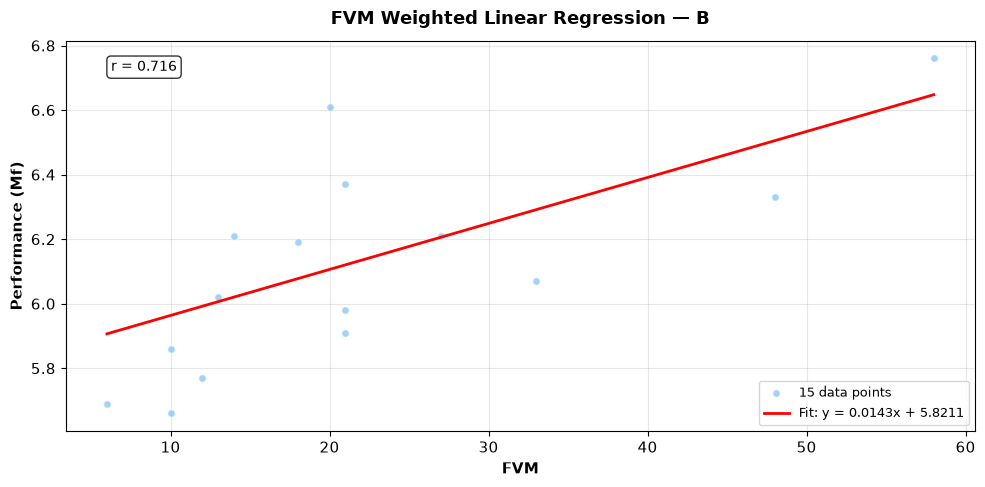

B: r=0.716, slope=0.0143, intercept=5.8211, n=15



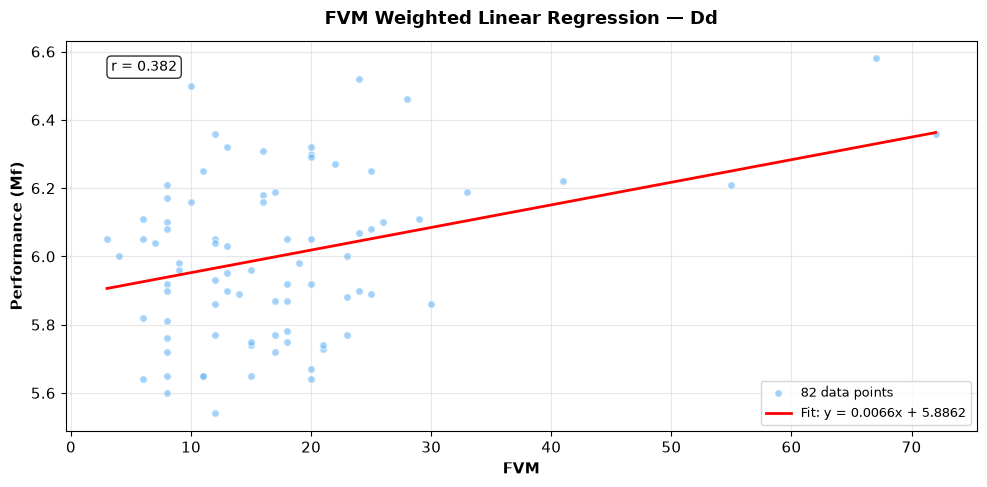

Dd: r=0.382, slope=0.0066, intercept=5.8862, n=82



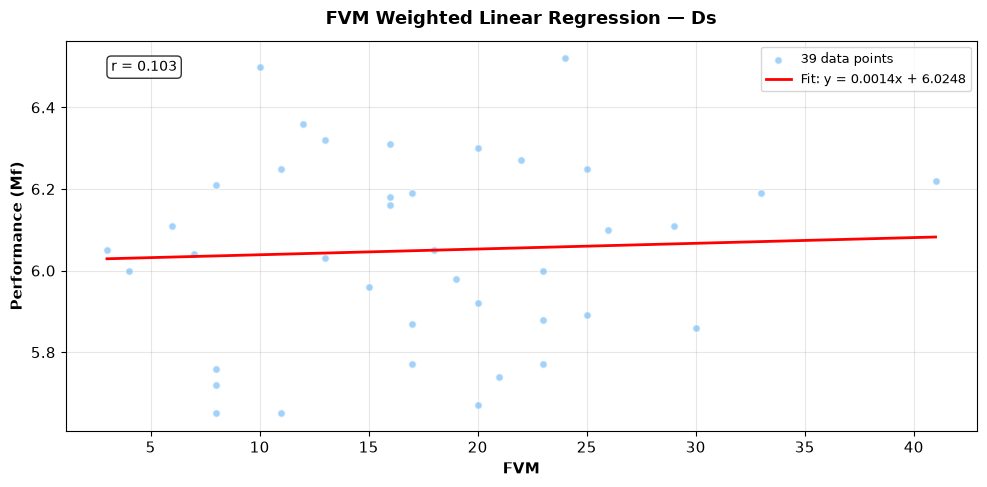

Ds: r=0.103, slope=0.0014, intercept=6.0248, n=39



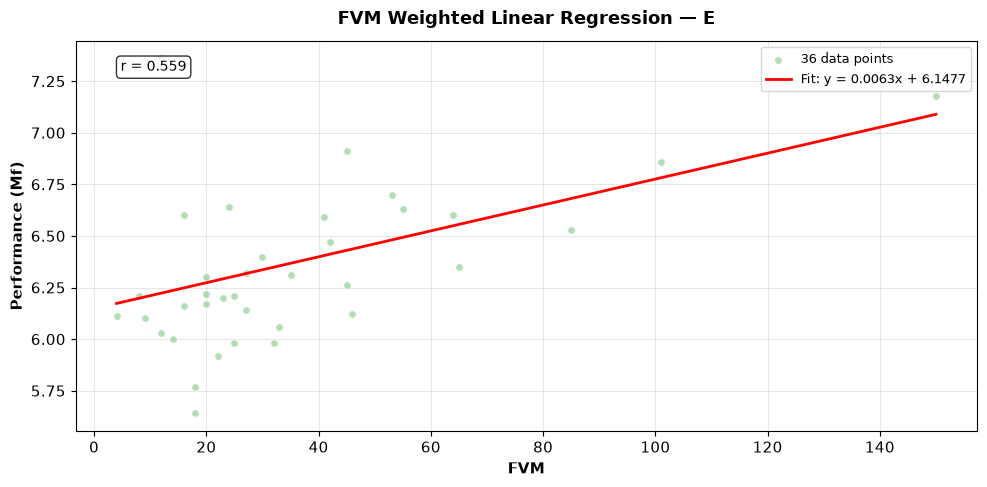

E: r=0.559, slope=0.0063, intercept=6.1477, n=36



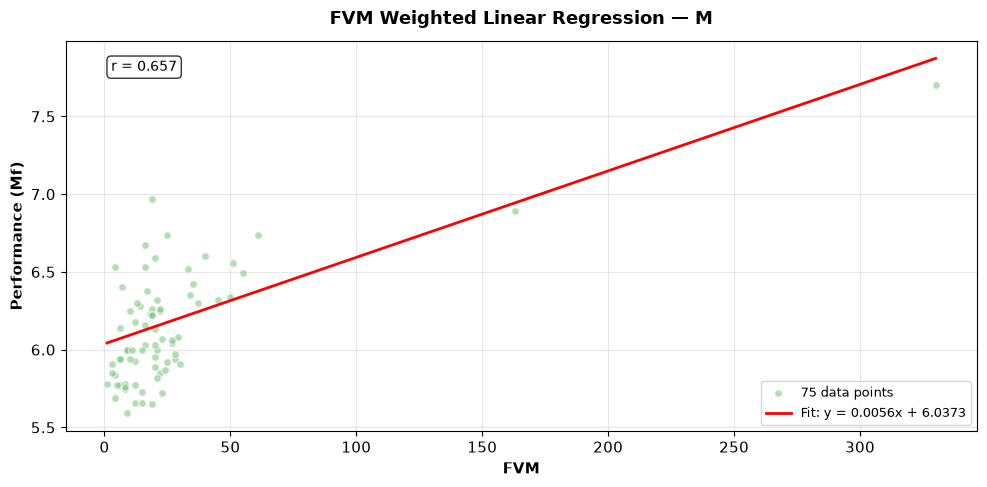

M: r=0.657, slope=0.0056, intercept=6.0373, n=75



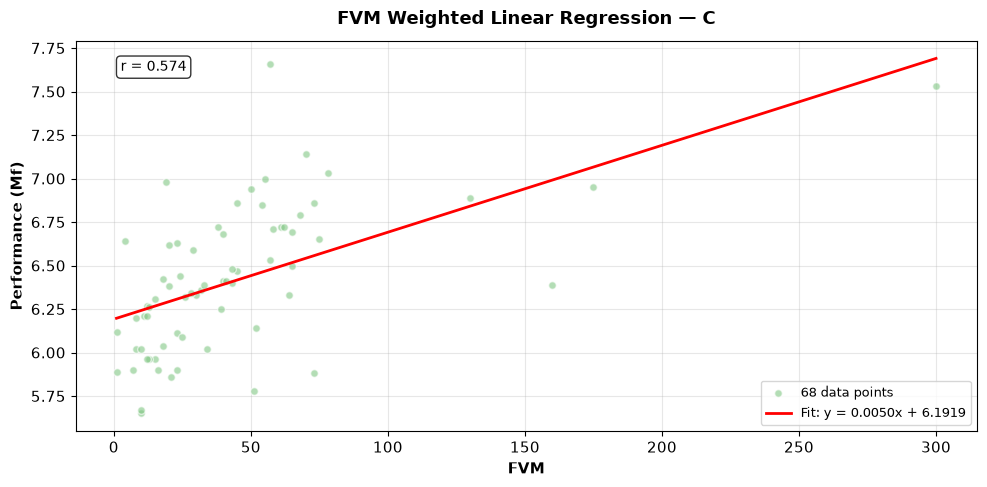

C: r=0.574, slope=0.0050, intercept=6.1919, n=68



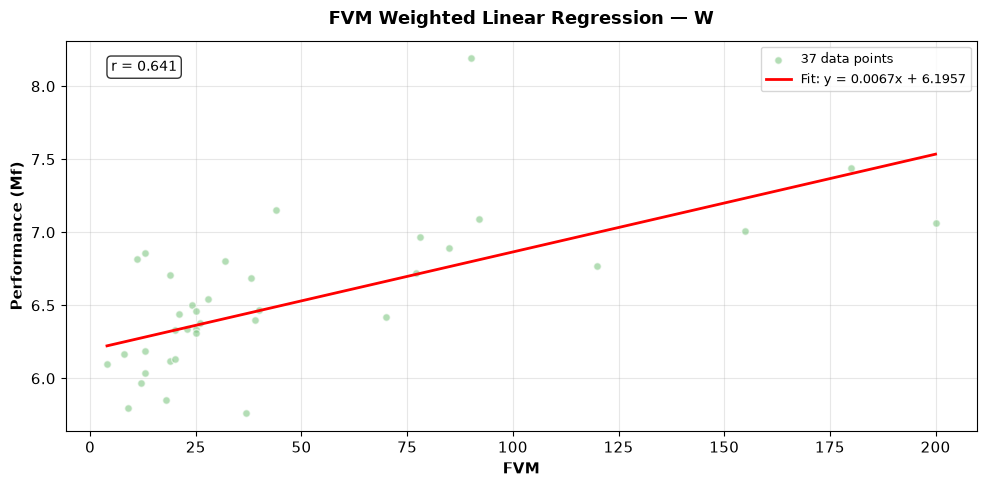

W: r=0.641, slope=0.0067, intercept=6.1957, n=37



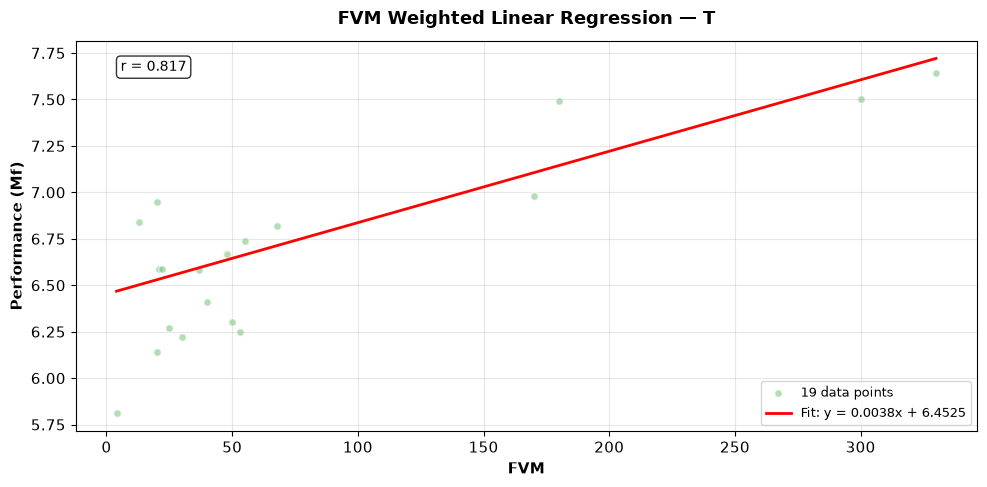

T: r=0.817, slope=0.0038, intercept=6.4525, n=19



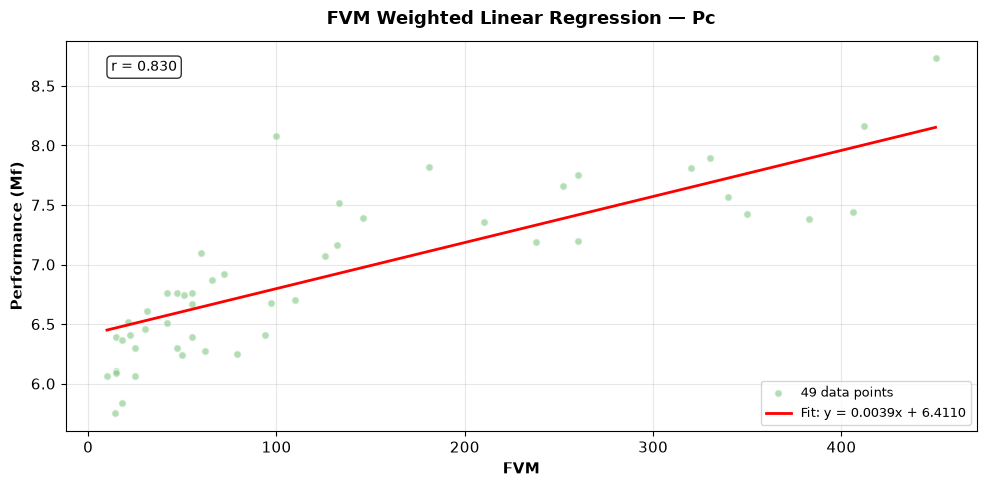

Pc: r=0.830, slope=0.0039, intercept=6.4110, n=49



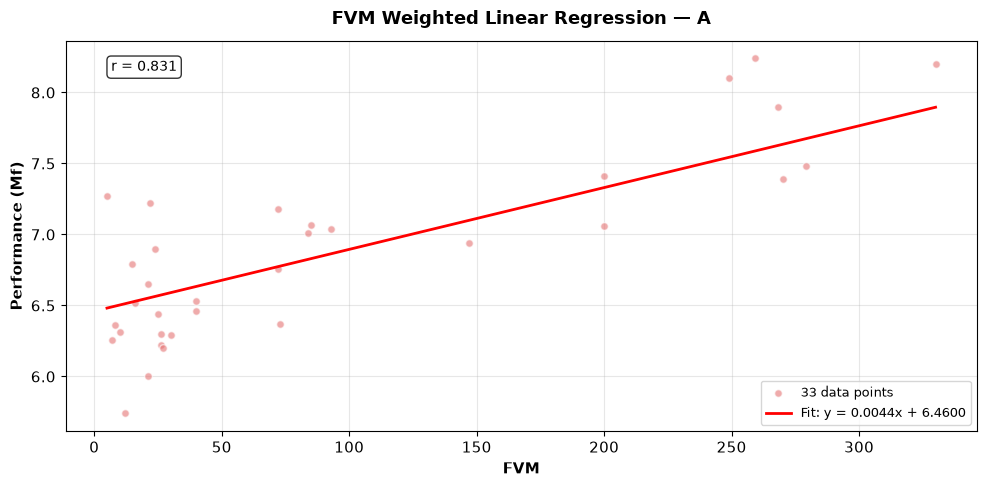

A: r=0.831, slope=0.0044, intercept=6.4600, n=33



In [109]:
# FVM linear regression plots
for i, model in enumerate(fvm_models):
    if model is None:
        continue
    role = roles_m[i]
    color = get_role_color(role)
    df_temp = df_m[i]
    players = []
    for _, row in df_temp.iterrows():
        for j, s in enumerate(seasons):
            fvm_col = f'FVM{s}'
            mf_col = f'Mf{s}'
            pg_col = f'Pg{s}'
            if pg_col in row and mf_col in row and fvm_col in row:
                try:
                    pg_val = row[pg_col]
                    if pd.notna(pg_val) and pg_val >= fvm_curve_min_games:
                        fvm_val = row[fvm_col]
                        mf_val = row[mf_col]
                        if pd.notna(fvm_val) and pd.notna(mf_val) and fvm_val > 0 and mf_val > 0:
                            players.append({'Name': row['Name'], 'FVM': fvm_val, 'MfPerformance': mf_val})
                except Exception:
                    pass
    new_df = pd.DataFrame(players)
    if len(new_df) == 0:
        continue
    x_min, x_max = new_df['FVM'].min(), new_df['FVM'].max()
    myline = np.linspace(x_min, x_max, 100)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(new_df['FVM'], new_df['MfPerformance'], color=color, s=30, alpha=0.6, edgecolors='white', zorder=2,
               label=f'{len(new_df)} data points')
    ax.plot(myline, model(myline), 'r-', linewidth=2, label=f'Fit: y = {model.coef[0]:.4f}x + {model.coef[1]:.4f}', zorder=3)
    ax.set_xlabel('FVM', fontweight='bold')
    ax.set_ylabel('Performance (Mf)', fontweight='bold')
    ax.set_title(f'FVM Weighted Linear Regression — {role}', fontweight='bold', pad=12)
    # Correlation
    corr = np.corrcoef(new_df['FVM'].values, new_df['MfPerformance'].values)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'{role}: r={corr:.3f}, slope={model.coef[0]:.4f}, intercept={model.coef[1]:.4f}, n={len(new_df)}')
    print()




## Spot check — key players


In [110]:
for name in ['Malen','Martinez L.', 'Hojlund', 'Gudmundsson', 'Zaniolo', 'Pulisic', 'Sommer', 'Raspadori', 'Dimarco']:
    row = df[df['Name']==name]
    if not row.empty:
        print(f"{name}: ExpectedMf={row['ExpectedMf'].values[0]}")


Malen: ExpectedMf=7.83
Martinez L.: ExpectedMf=7.59
Hojlund: ExpectedMf=7.24
Zaniolo: ExpectedMf=6.72
Pulisic: ExpectedMf=6.97
Sommer: ExpectedMf=5.18
Raspadori: ExpectedMf=6.74
Dimarco: ExpectedMf=7.9


## Validation

Checks that ExpectedMf values fall within plausible bounds per role:
- **P**: 3.0 — 6.0
- **D**: 4.0 — 7.5
- **C**: 4.0 — 9.0
- **A**: 4.5 — 10.0


In [111]:
bounds = {'P':(3,6),'D':(4,7.5),'C':(4,9),'A':(4.5,10)}
report = {}
for role, (lo,hi) in bounds.items():
    vals = df.loc[df['Role']==role,'ExpectedMf']
    report[role] = {'count':int(len(vals)),'mean':float(vals.mean()),'out_of_bounds':int(((vals<lo)|(vals>hi)).sum())}
report['myrating_ok'] = True
with open(f"{INTER_DIR}/validation_stage1.json","w") as f:
    json.dump(report,f,indent=2)
print(json.dumps(report,indent=2))


{
  "P": {
    "count": 67,
    "mean": 4.834925373134329,
    "out_of_bounds": 0
  },
  "D": {
    "count": 184,
    "mean": 6.007228260869565,
    "out_of_bounds": 1
  },
  "C": {
    "count": 178,
    "mean": 6.308483146067416,
    "out_of_bounds": 0
  },
  "A": {
    "count": 103,
    "mean": 6.636407766990292,
    "out_of_bounds": 0
  },
  "myrating_ok": true
}


In [112]:
df.to_csv(OUTPUT_PATH, index=False)
